# HMPNN on IBM HI-Small: repository architecture reproduction

This notebook runs the **original two-layer HMPNN-sum and HMPNN-ct model classes** from
[fredjo89/heterogeneous-mpnn](https://github.com/fredjo89/heterogeneous-mpnn), pinned to
`4f56e6a38a7e35fd186393c1849f2711392c908b`. The source and MIT license are preserved in
`vendor/heterogeneous-mpnn`. Paper: [Finding Money Launderers Using Heterogeneous Graph Neural Networks](https://arxiv.org/abs/2307.13499).

**Scope:** reproduce the model architectures and adapt the experiment to the local IBM
HI-Small data. The paper's private DNB data, customer labels, business-role graph and
features are unavailable. The repository's public example uses IMDB, not IBM.
Consequently these are **new IBM experimental metrics, not reproduced paper scores**.

The graph has account and entity node types, directed payment-format relations with
reverse relations, and account/entity ownership links. An account is positive if it
sends or receives at least one labeled laundering transaction **in the sampled data**.
This is a sampled, retrospective account-detection proxy. Negatives can include
accounts whose positive transactions were not sampled. Labels never enter features
or message passing. The pattern-annotation file is not read.

Run all cells using the project's `.venv` Python kernel. Dependencies: torch,
torch_geometric, pandas, numpy, scikit-learn, matplotlib, nbformat, and IPython.
Outputs are written to `HMPNN/hmpnn_results`.

In [1]:
from pathlib import Path
import copy, hashlib, importlib.metadata, json, os, random, sys, time, warnings
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch_geometric.data import HeteroData
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
    roc_curve, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix)
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'Data').exists():
    ROOT = ROOT.parent
assert (ROOT / 'Data' / 'HI-Small_Trans.csv').exists(), 'Run from the project root or HMPNN folder.'
VENDOR = ROOT / 'HMPNN' / 'vendor' / 'heterogeneous-mpnn'
sys.path.insert(0, str(VENDOR))
import models_HMPNN_ct, models_HMPNN_sum
assert (VENDOR / 'COMMIT.txt').read_text().strip() == '4f56e6a38a7e35fd186393c1849f2711392c908b'
OUT = ROOT / 'HMPNN' / 'hmpnn_results'
OUT.mkdir(exist_ok=True)
SEED = 42
MAX_ROWS = 100_000  # Uniform transaction sample; increase for a larger experiment.
CHUNK_SIZE = 250_000
MAX_EPOCHS = 300
MIN_EPOCHS = 50
PATIENCE = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_num_threads(min(4, os.cpu_count() or 1))
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
versions = {p: importlib.metadata.version(p) for p in
            ['torch', 'torch_geometric', 'pandas', 'numpy', 'scikit-learn', 'matplotlib']}
print('Device:', DEVICE, '| versions:', versions)

D:\AntiMoneyLaundering_FF_detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


D:\AntiMoneyLaundering_FF_detection\.venv\Lib\site-packages\torch\jit\_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Matplotlib is building the font cache; this may take a moment.


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\syamp\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Device: cpu | versions: {'torch': '2.14.0', 'torch_geometric': '2.8.0.post1', 'pandas': '3.0.6', 'numpy': '2.5.3', 'scikit-learn': '1.9.1', 'matplotlib': '3.11.2'}


## 1. Label-independent transaction sampling

Assign every transaction an independent random priority and keep the smallest
100,000 priorities across the whole file. This is a uniform sample without replacement,
not a first-rows sample or positive-class oversample. Chunked reading bounds memory.
Sample row IDs are exported. Bank IDs are normalized numerically to reconcile leading
zeros between files; account identifiers remain strings.

In [2]:
COLS = ['Timestamp', 'From Bank', 'From Account', 'To Bank', 'To Account',
        'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency',
        'Payment Format', 'Is Laundering']
dtypes = {c: 'string' for c in ['From Bank', 'From Account', 'To Bank', 'To Account',
                              'Receiving Currency', 'Payment Currency', 'Payment Format']}
dtypes['Is Laundering'] = 'int8'
rng = np.random.default_rng(SEED)
sample = None
rows_seen = 0
source_positive_count = 0
for chunk in pd.read_csv(ROOT / 'Data' / 'HI-Small_Trans.csv', header=0, names=COLS,
                         dtype=dtypes, chunksize=CHUNK_SIZE):
    source_positive_count += int(chunk['Is Laundering'].sum())
    chunk['_row_id'] = np.arange(rows_seen, rows_seen + len(chunk))
    rows_seen += len(chunk)
    chunk['_priority'] = rng.random(len(chunk))
    chunk = chunk.nsmallest(min(MAX_ROWS, len(chunk)), '_priority')
    sample = chunk if sample is None else pd.concat([sample, chunk], ignore_index=True)
    sample = sample.nsmallest(min(MAX_ROWS, len(sample)), '_priority')
tx = sample.drop(columns='_priority').copy()
del sample, chunk
tx['Timestamp'] = pd.to_datetime(tx['Timestamp'], format='%Y/%m/%d %H:%M', errors='raise')
assert tx[['Timestamp', 'From Account', 'To Account']].notna().all().all()
for c in ['From Bank', 'To Bank']:
    tx[c] = pd.to_numeric(tx[c], errors='raise').astype('int64').astype(str)
for c in ['Amount Paid', 'Amount Received']:
    tx[c] = pd.to_numeric(tx[c], errors='raise')
    assert np.isfinite(tx[c]).all() and (tx[c] >= 0).all()
tx = tx.sort_values(['Timestamp', '_row_id'], kind='stable').reset_index(drop=True)
tx['from_key'] = tx['From Bank'] + ':' + tx['From Account']
tx['to_key'] = tx['To Bank'] + ':' + tx['To Account']
tx['log_paid'] = np.log1p(tx['Amount Paid']).astype('float32')
tx['log_received'] = np.log1p(tx['Amount Received']).astype('float32')
tx[['_row_id']].to_csv(OUT / 'sample_row_ids.csv', index=False)
accounts = pd.read_csv(ROOT / 'Data' / 'HI-Small_accounts.csv', dtype='string')
accounts['Bank ID'] = pd.to_numeric(accounts['Bank ID'], errors='raise').astype('int64').astype(str)
accounts['key'] = accounts['Bank ID'] + ':' + accounts['Account Number']
assert not accounts['key'].duplicated().any()
print(f'Source rows: {rows_seen:,}; source positives: {source_positive_count:,}')
print(f'Sampled rows: {len(tx):,}; sampled positives: {tx["Is Laundering"].sum():,}')
print('Sample dates:', tx.Timestamp.min(), 'through', tx.Timestamp.max())
display(tx.head())

Source rows: 5,078,345; source positives: 5,177
Sampled rows: 100,000; sampled positives: 99
Sample dates: 2022-09-01 00:00:00 through 2022-09-16 12:36:00


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,_row_id,from_key,to_key,log_paid,log_received
0,2022-09-01,12,80024EBB0,12,80024EBB0,18.27,US Dollar,18.27,US Dollar,Reinvestment,0,840,12:80024EBB0,12:80024EBB0,2.958549,2.958549
1,2022-09-01,1362,80089D390,701,800ACD480,38457.45,US Dollar,38457.45,US Dollar,Cheque,0,6127,1362:80089D390,701:800ACD480,10.557334,10.557334
2,2022-09-01,10,8003A69A0,1124,800B421D0,12571.00,US Dollar,12571.00,US Dollar,Cheque,0,6402,10:8003A69A0,1124:800B421D0,9.439227,9.439227
3,2022-09-01,1588,800BB5C30,1588,800BB5C30,5.57,US Dollar,5.57,US Dollar,Reinvestment,0,6586,1588:800BB5C30,1588:800BB5C30,1.882514,1.882514
4,2022-09-01,1467,800C29330,1467,800C29330,14.44,US Dollar,14.44,US Dollar,Reinvestment,0,7012,1467:800C29330,1467:800C29330,2.736962,2.736962


## 2. Targets and held-out account split

As in the repository demonstration, use a stratified random 60/20/20 node split on one
static graph. Unlabeled graph structure and node attributes are visible across splits
(transductive evaluation); validation and test labels are not used for fitting.
Accounts belonging to the same entity can span splits, so this does not estimate
generalization to unseen entities. A prospective or entity-disjoint study needs a
different split and feature construction. A single laundering transaction can mark
both endpoints positive in different splits; account labels are therefore correlated.
This is not an independent held-out transaction evaluation.

In [3]:
node_keys = pd.Index(pd.concat([tx.from_key, tx.to_key], ignore_index=True).unique())
tx['src'] = node_keys.get_indexer(tx.from_key)
tx['dst'] = node_keys.get_indexer(tx.to_key)
n_accounts = len(node_keys)
labels = np.zeros(n_accounts, dtype=np.int64)
np.maximum.at(labels, tx.src.to_numpy(), tx['Is Laundering'].to_numpy())
np.maximum.at(labels, tx.dst.to_numpy(), tx['Is Laundering'].to_numpy())
indices = np.arange(n_accounts)
train_idx, heldout_idx = train_test_split(indices, test_size=0.4, stratify=labels, random_state=SEED)
val_idx, test_idx = train_test_split(heldout_idx, test_size=0.5,
                                  stratify=labels[heldout_idx], random_state=SEED)
split_indices = {'train': train_idx, 'validation': val_idx, 'test': test_idx}
assert not (set(train_idx) & set(val_idx) or set(train_idx) & set(test_idx) or set(val_idx) & set(test_idx))
assert sum(map(len, split_indices.values())) == n_accounts
split_table = pd.DataFrame([{'split': s, 'accounts': len(i), 'positives': int(labels[i].sum()),
                            'prevalence': float(labels[i].mean())} for s, i in split_indices.items()])
assert (split_table.positives >= 2).all(), 'Increase MAX_ROWS to obtain enough positives in each split.'
display(split_table)

,split,accounts,positives,prevalence
0,train,71441,115,0.001610
1,validation,23814,38,0.001596
2,test,23814,38,0.001596


## 3. Heterogeneous graph and label-free features

Account features: log outgoing/incoming counts, mean log outgoing/incoming amounts,
self-transfer fraction, and activity span in days. Entity features average these
account features, replacing the last feature with log linked-account count. These
features use the complete sampled static graph, including held-out nodes, by design.
Account scaling is fitted only on training accounts; entity scaling uses entities
linked to training accounts. No account ID or entity ID is a numeric feature.

Payment edges carry standardized log paid amount, log received amount, relative time,
same-currency indicator and payment-currency one-hot indicators. Nominal amounts are
not FX-converted. Their interpretation depends on currency. Edge scaling uses payments
whose source account is in training. Reverse edges preserve transaction attributes.
Ownership edges have a constant feature of one. Missing entity metadata gets a unique
placeholder per account, never a shared artificial entity.

In [4]:
src, dst = tx.src.to_numpy(), tx.dst.to_numpy()
out_count = np.bincount(src, minlength=n_accounts)
in_count = np.bincount(dst, minlength=n_accounts)
mean_out = np.bincount(src, weights=tx.log_paid, minlength=n_accounts) / np.maximum(out_count, 1)
mean_in = np.bincount(dst, weights=tx.log_received, minlength=n_accounts) / np.maximum(in_count, 1)
self_count = np.bincount(src[src == dst], minlength=n_accounts)
days = ((tx.Timestamp - tx.Timestamp.min()).dt.total_seconds() / 86400).to_numpy()
first = np.full(n_accounts, np.inf); last = np.full(n_accounts, -np.inf)
for ids in [src, dst]:
    np.minimum.at(first, ids, days); np.maximum.at(last, ids, days)
raw_x = np.column_stack([np.log1p(out_count), np.log1p(in_count), mean_out, mean_in,
                         self_count / np.maximum(out_count, 1), last - first]).astype('float32')
entity_for_account = accounts.set_index('key')['Entity ID'].reindex(node_keys)
missing_entities = int(entity_for_account.isna().sum())
entity_for_account = entity_for_account.fillna(pd.Series('missing:' + node_keys, index=node_keys))
entity_ids, entity_keys = pd.factorize(entity_for_account, sort=True)
n_entities = len(entity_keys)
entity_count = np.bincount(entity_ids, minlength=n_entities)
raw_entity_x = np.zeros((n_entities, raw_x.shape[1]), dtype=np.float32)
np.add.at(raw_entity_x, entity_ids, raw_x)
raw_entity_x /= entity_count[:, None]
raw_entity_x[:, -1] = np.log1p(entity_count)
account_scaler = StandardScaler().fit(raw_x[train_idx])
entity_scaler = StandardScaler().fit(raw_entity_x[np.unique(entity_ids[train_idx])])
data = HeteroData()
data['account'].x = torch.tensor(account_scaler.transform(raw_x), dtype=torch.float32)
data['entity'].x = torch.tensor(entity_scaler.transform(raw_entity_x), dtype=torch.float32)
data['account'].y = torch.tensor(labels, dtype=torch.float32).reshape(-1, 1)
for split, idx in split_indices.items():
    mask = torch.zeros(n_accounts, dtype=torch.bool); mask[idx] = True
    data['account'][split + '_mask'] = mask
edge_numeric = np.column_stack([tx.log_paid, tx.log_received, days]).astype('float32')
edge_fit_mask = np.isin(src, train_idx)
edge_scaler = StandardScaler().fit(edge_numeric[edge_fit_mask])
currency = pd.get_dummies(tx['Payment Currency'].fillna('UNKNOWN'), dtype=np.float32)
edge_features = np.column_stack([edge_scaler.transform(edge_numeric),
    (tx['Payment Currency'] == tx['Receiving Currency']).to_numpy(dtype=np.float32),
    currency.to_numpy()]).astype('float32')
relation_names = sorted(tx['Payment Format'].fillna('UNKNOWN').unique().tolist())
for r, name in enumerate(relation_names):
    select = (tx['Payment Format'].fillna('UNKNOWN') == name).to_numpy()
    edge_index = torch.tensor(np.stack([src[select], dst[select]]), dtype=torch.long)
    attr = torch.tensor(edge_features[select], dtype=torch.float32)
    data['account', f'payment_{r}', 'account'].edge_index = edge_index
    data['account', f'payment_{r}', 'account'].edge_attr = attr
    data['account', f'reverse_payment_{r}', 'account'].edge_index = edge_index.flip(0)
    data['account', f'reverse_payment_{r}', 'account'].edge_attr = attr.clone()
ownership = torch.tensor(np.stack([entity_ids, np.arange(n_accounts)]), dtype=torch.long)
data['entity', 'owns', 'account'].edge_index = ownership
data['entity', 'owns', 'account'].edge_attr = torch.ones(n_accounts, 1)
data['account', 'owned_by', 'entity'].edge_index = ownership.flip(0)
data['account', 'owned_by', 'entity'].edge_attr = torch.ones(n_accounts, 1)
assert data.validate(raise_on_error=True)
assert all(torch.isfinite(x).all() for x in data.x_dict.values())
assert all(torch.isfinite(x).all() for x in data.edge_attr_dict.values())
split_names = np.full(n_accounts, '', dtype=object)
for s, idx in split_indices.items(): split_names[idx] = s
account_export = pd.DataFrame({'account_key': node_keys, 'entity_id': np.asarray(entity_for_account),
                               'split': split_names, 'label': labels})
account_export.to_csv(OUT / 'account_splits.csv', index=False)
split_table.to_csv(OUT / 'split_summary.csv', index=False)
print(f'Accounts: {n_accounts:,}; entities: {n_entities:,}; missing entity metadata: {missing_entities:,}')
print('Payment relation mapping:', dict(enumerate(relation_names)))
print('Total directed edges:', sum(data[e].num_edges for e in data.edge_types))
display(pd.DataFrame([{'relation': str(e), 'edges': data[e].num_edges,
                       'features': data[e].edge_attr.shape[1]} for e in data.edge_types]))
data = data.to(DEVICE)

Accounts: 119,069; entities: 87,487; missing entity metadata: 0
Payment relation mapping: {0: 'ACH', 1: 'Bitcoin', 2: 'Cash', 3: 'Cheque', 4: 'Credit Card', 5: 'Reinvestment', 6: 'Wire'}
Total directed edges: 438138


,relation,edges,features
0,"('account', 'payment_0', 'account')",11750,19
1,"('account', 'reverse_payment_0', 'account')",11750,19
2,"('account', 'payment_1', 'account')",2956,19
3,"('account', 'reverse_payment_1', 'account')",2956,19
4,"('account', 'payment_2', 'account')",9431,19
5,"('account', 'reverse_payment_2', 'account')",9431,19
6,"('account', 'payment_3', 'account')",36796,19
7,"('account', 'reverse_payment_3', 'account')",36796,19
8,"('account', 'payment_4', 'account')",26190,19
9,"('account', 'reverse_payment_4', 'account')",26190,19


## 4. Original HMPNN architectures and training

For each typed relation, PyG `NNConv` learns an edge-conditioned matrix, transforms
source features, sums neighbor messages, and adds a destination root transformation
and bias. **HMPNN-sum** sums relation outputs and applies sigmoid. **HMPNN-ct** applies
sigmoid to each relation output, concatenates them in fixed order, and applies a
learned linear map followed by sigmoid. The original two-layer classes are imported
unchanged. HMPNN-ct uses message widths 2 then 10 and a hidden output width of 5.
This model is not the GRU/attention/ACP prototype in `AML.ipynb`.

Both use Adam, unweighted binary cross-entropy and the same split, learning rate and
epoch budget. No label resampling or class weighting is used. Validation BCE chooses
the checkpoint; validation F1 chooses the decision threshold afterward. The original
training helper's reference-based checkpoint is replaced with a deep-copied state
dictionary, and validation is evaluated after each update. This experiment uses two
layers and at most 300 epochs for CPU feasibility; the repository's IMDB example uses
three layers and up to 10,000 epochs. One seed is run; no uncertainty claim is made.
A logistic regression baseline uses the same account features and split.

In [5]:
def forward_model(model):
    # A fresh dictionary also prevents the upstream sum class's dictionary updates
    # from replacing the original graph feature tensors.
    return model(dict(data.x_dict), data.edge_index_dict, data.edge_attr_dict)

def train_model(model, name):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.BCELoss()
    best_loss, best_epoch, bad_epochs = float('inf'), 0, 0
    best_state = None
    history = []
    started = time.perf_counter()
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train(); opt.zero_grad(set_to_none=True)
        pred = forward_model(model)
        loss = criterion(pred[data['account'].train_mask], data['account'].y[data['account'].train_mask])
        assert torch.isfinite(loss), 'Non-finite loss'
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            pred = forward_model(model)
            val_loss = criterion(pred[data['account'].validation_mask],
                                 data['account'].y[data['account'].validation_mask]).item()
        history.append({'epoch': epoch, 'train_bce': loss.item(), 'validation_bce': val_loss})
        if val_loss < best_loss:
            best_loss, best_epoch, bad_epochs = val_loss, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            bad_epochs += 1
        if epoch == 1 or epoch % 25 == 0:
            print(f'{name}: epoch {epoch:3d}, train BCE {loss.item():.6f}, val BCE {val_loss:.6f}, '
                  f'elapsed {time.perf_counter()-started:.1f}s', flush=True)
        if epoch >= MIN_EPOCHS and bad_epochs >= PATIENCE:
            break
    assert best_state is not None
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        probabilities = forward_model(model).flatten().cpu().numpy()
    torch.save({'state_dict': {k: v.cpu() for k, v in best_state.items()},
                'model': name, 'best_epoch': best_epoch, 'seed': SEED}, OUT / f'{name}.pt')
    hist = pd.DataFrame(history); hist.to_csv(OUT / f'{name}_history.csv', index=False)
    metadata = {'model': name, 'best_epoch': best_epoch, 'epochs_run': epoch,
                'hit_epoch_cap': epoch == MAX_EPOCHS, 'best_validation_bce': best_loss,
                'parameters': sum(p.numel() for p in model.parameters()),
                'training_seconds': time.perf_counter() - started}
    print(metadata, flush=True)
    return probabilities, hist, metadata

predictions, histories, training_info = {}, {}, []
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(account_scaler.transform(raw_x)[train_idx], labels[train_idx])
predictions['LogisticRegression'] = lr.predict_proba(account_scaler.transform(raw_x))[:, 1]
for name, model_class in [('HMPNN_sum', models_HMPNN_sum.HMPNN_sum_2Layer),
                          ('HMPNN_ct', models_HMPNN_ct.HMPNN_ct_2Layer)]:
    torch.manual_seed(SEED)
    # PyG warns because an individual typed operator updates only its destination;
    # the complete heterogeneous layer covers both node types.
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='There exist node types.*', category=UserWarning)
        model = model_class(data, node_type='account')
    predictions[name], histories[name], info = train_model(model, name)
    training_info.append(info)
    del model
display(pd.DataFrame(training_info))

HMPNN_sum: epoch   1, train BCE 1.261742, val BCE 1.193830, elapsed 1.7s


HMPNN_sum: epoch  25, train BCE 0.247306, val BCE 0.231342, elapsed 19.6s


HMPNN_sum: epoch  50, train BCE 0.081256, val BCE 0.077213, elapsed 38.0s


HMPNN_sum: epoch  75, train BCE 0.050548, val BCE 0.047241, elapsed 57.0s


HMPNN_sum: epoch 100, train BCE 0.038992, val BCE 0.035811, elapsed 76.4s


...

HMPNN_ct: epoch 250, train BCE 0.014013, val BCE 0.013911, elapsed 278.0s


HMPNN_ct: epoch 275, train BCE 0.013469, val BCE 0.013380, elapsed 302.7s


HMPNN_ct: epoch 300, train BCE 0.013055, val BCE 0.012977, elapsed 327.0s


{'model': 'HMPNN_ct', 'best_epoch': 300, 'epochs_run': 300, 'hit_epoch_cap': True, 'best_validation_bce': 0.01297671813517809, 'parameters': 18953, 'training_seconds': 327.4611071999825}


,model,best_epoch,epochs_run,hit_epoch_cap,best_validation_bce,parameters,training_seconds
0,HMPNN_sum,300,300,True,0.017861,12693,230.152652
1,HMPNN_ct,300,300,True,0.012977,18953,327.461107


## 5. Held-out metrics

Thresholds maximize validation F1 and are frozen before test evaluation. PR-AUC below
means **average precision (AP)**, not trapezoidal integration. ROC-AUC, F1, precision,
recall, accuracy, confusion counts and Precision/Recall@K are computed on test accounts.
Accuracy can be misleading at low prevalence. Top-K sorts descending probability;
ties retain fixed node order. A no-skill AP reference equals test prevalence.
The threshold-0.5 F1 is also reported to expose the effect of threshold selection.

In [6]:
def select_threshold(y, p):
    precision, recall, thresholds = precision_recall_curve(y, p)
    scores = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    return float(thresholds[np.argmax(scores)])

def metric_row(y, p, threshold):
    hard = p >= threshold
    tn, fp, fn, tp = confusion_matrix(y, hard, labels=[0, 1]).ravel()
    result = {'PR_AUC_AP': average_precision_score(y, p), 'ROC_AUC': roc_auc_score(y, p),
              'F1': f1_score(y, hard, zero_division=0),
              'Precision': precision_score(y, hard, zero_division=0),
              'Recall': recall_score(y, hard, zero_division=0),
              'Accuracy': accuracy_score(y, hard),
              'F1_at_0.5': f1_score(y, p >= 0.5, zero_division=0),
              'Threshold': threshold, 'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
              'Accounts': len(y), 'Positives': int(y.sum()), 'Prevalence': float(y.mean())}
    order = np.argsort(-p, kind='stable')
    for k in [100, 500, 1000]:
        top = y[order[:min(k, len(y))]]
        result[f'Precision@{k}'] = float(top.mean())
        result[f'Recall@{k}'] = float(top.sum() / y.sum())
    return result

rows, thresholds = [], {}
for name, p in predictions.items():
    assert p.shape == labels.shape and np.isfinite(p).all() and ((p >= 0) & (p <= 1)).all()
    threshold = select_threshold(labels[val_idx], p[val_idx]); thresholds[name] = threshold
    for split in ['validation', 'test']:
        idx = split_indices[split]
        rows.append({'Model': name, 'Split': split, **metric_row(labels[idx], p[idx], threshold)})
metrics = pd.DataFrame(rows)
metrics.to_csv(OUT / 'metrics.csv', index=False)
test_metrics = metrics[metrics.Split == 'test'].set_index('Model')
display(test_metrics[['PR_AUC_AP', 'ROC_AUC', 'F1', 'Precision', 'Recall',
                      'Precision@100', 'Recall@100', 'F1_at_0.5']].round(6))
print('Test prevalence / no-skill AP:', labels[test_idx].mean())
print('Test accounts:', len(test_idx), '| positives:', labels[test_idx].sum())
prediction_export = account_export.copy()
for name, p in predictions.items(): prediction_export[name] = p
prediction_export.to_csv(OUT / 'predictions.csv', index=False)

def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''): h.update(chunk)
    return h.hexdigest()

manifest = {'repository': 'https://github.com/fredjo89/heterogeneous-mpnn',
    'commit': (VENDOR / 'COMMIT.txt').read_text().strip(), 'versions': versions,
    'seed': SEED, 'max_rows': MAX_ROWS, 'source_rows': rows_seen, 'sample_rows': len(tx),
    'chunk_size': CHUNK_SIZE, 'device': str(DEVICE), 'layers': 2,
    'max_epochs': MAX_EPOCHS, 'min_epochs': MIN_EPOCHS, 'patience': PATIENCE,
    'learning_rate': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY,
    'split': 'static transductive stratified account split 60/20/20',
    'target': 'account participates in >=1 positive sampled transaction',
    'thresholds': thresholds, 'training': training_info,
    'sources': {name: {'bytes': (ROOT / 'Data' / name).stat().st_size,
                       'sha256': sha256(ROOT / 'Data' / name)}
                for name in ['HI-Small_Trans.csv', 'HI-Small_accounts.csv']},
    'vendor_sha256': {name: sha256(VENDOR / name)
                     for name in ['models_HMPNN_ct.py', 'models_HMPNN_sum.py']}}
(OUT / 'run_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
# Save graph, preprocessing and baseline for reproducible inference without refitting.
import pickle
torch.save(data.cpu(), OUT / 'graph.pt')
with open(OUT / 'preprocessing.pkl', 'wb') as handle:
    pickle.dump({'account_scaler': account_scaler, 'entity_scaler': entity_scaler,
                 'edge_scaler': edge_scaler, 'currencies': currency.columns.tolist(),
                 'relations': relation_names, 'logistic_regression': lr}, handle)
print('Saved metrics, predictions, graph, checkpoints, preprocessing, splits and run manifest:', OUT)

,PR_AUC_AP,ROC_AUC,F1,Precision,Recall,Precision@100,Recall@100,F1_at_0.5
Model,,,,,,,,
LogisticRegression,0.015572,0.650003,0.05,0.5,0.026316,0.01,0.026316,0.0
HMPNN_sum,0.003810,0.672603,0.00,0.0,0.000000,0.00,0.000000,0.0
HMPNN_ct,0.011529,0.762060,0.00,0.0,0.000000,0.00,0.000000,0.0


Test prevalence / no-skill AP: 0.001595700008398421
Test accounts: 23814 | positives: 38


Saved metrics, predictions, graph, checkpoints, preprocessing, splits and run manifest: D:\AntiMoneyLaundering_FF_detection\HMPNN\hmpnn_results


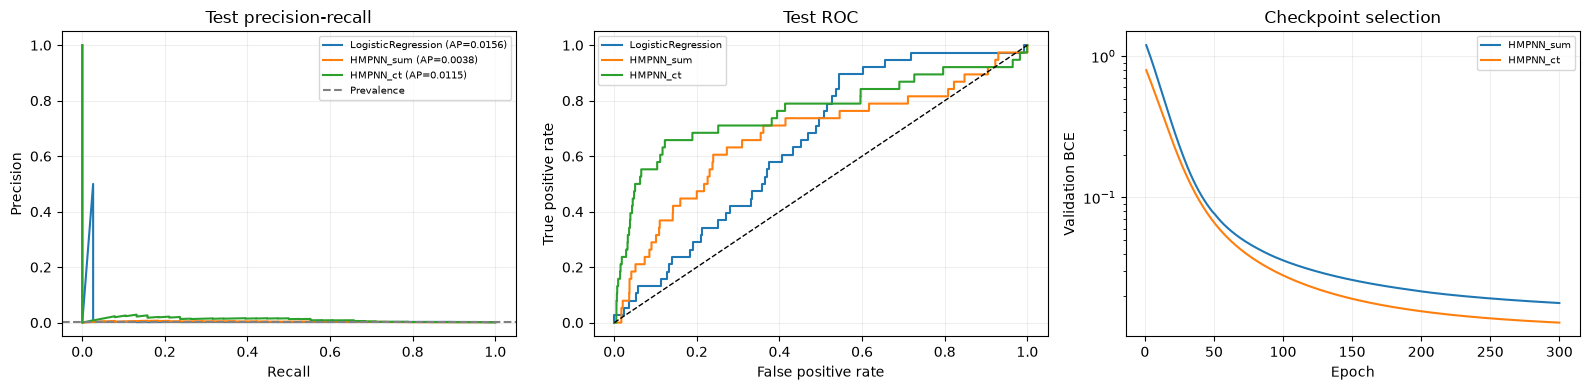

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for name, p in predictions.items():
    precision, recall, _ = precision_recall_curve(labels[test_idx], p[test_idx])
    axes[0].plot(recall, precision, label=f'{name} (AP={average_precision_score(labels[test_idx], p[test_idx]):.4f})')
    fpr, tpr, _ = roc_curve(labels[test_idx], p[test_idx])
    axes[1].plot(fpr, tpr, label=name)
axes[0].axhline(labels[test_idx].mean(), color='grey', linestyle='--', label='Prevalence')
axes[0].set(xlabel='Recall', ylabel='Precision', title='Test precision-recall')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set(xlabel='False positive rate', ylabel='True positive rate', title='Test ROC')
for name, hist in histories.items():
    axes[2].plot(hist.epoch, hist.validation_bce, label=name)
axes[2].set(xlabel='Epoch', ylabel='Validation BCE', title='Checkpoint selection', yscale='log')
for ax in axes: ax.legend(fontsize=7); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(OUT / 'evaluation.png', dpi=160, bbox_inches='tight')
plt.show()

## Interpretation and limitations

Use the held-out **test** rows in `metrics.csv` for reporting. Validation rows are
optimistic because they selected checkpoints and thresholds. Comparing both variants
on test is descriptive; choosing a winner and claiming a new unbiased score would need
another holdout. This run has one seed, sampled transactions, proxy account labels and
shared static graph context. It is neither a DNB replication nor a prospective AML
deployment evaluation. Small positive counts make F1 and top-K metrics variable.

Inspect `hit_epoch_cap` in the training metadata: hitting the cap does not establish
convergence. Larger samples, longer optimization, multiple seeds, and entity-disjoint
or chronological evaluation are separate follow-up experiments. This notebook does not
infer superior performance when HMPNN fails to beat the feature-only baseline.